/opt/anaconda3/envs/meep/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


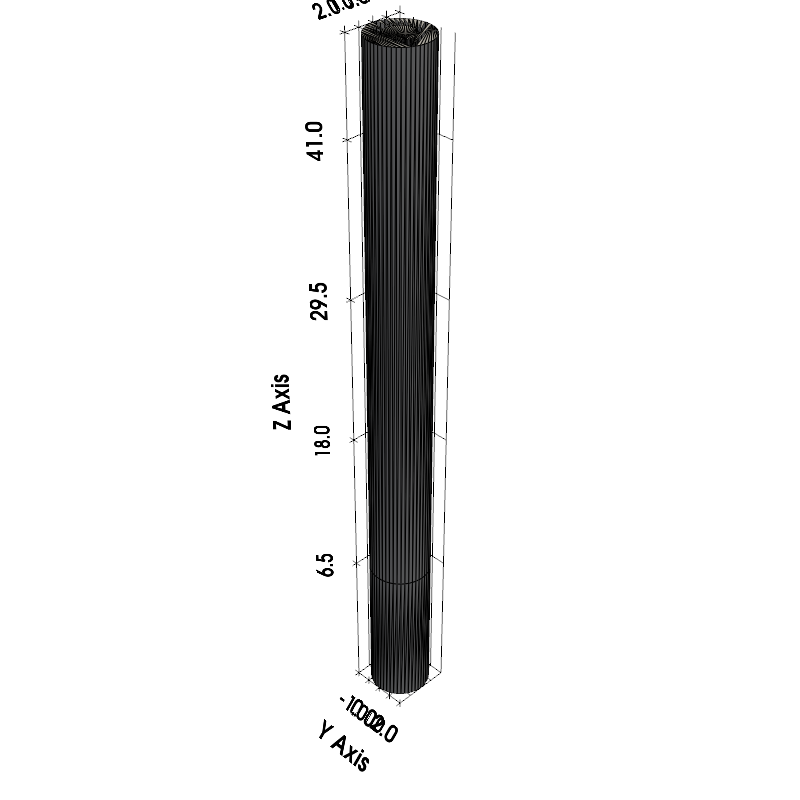

In [2]:
import meep as mp
import pyvista as pv
import numpy as np

# Note: The original 'make_hollow_horn' function is left for reference,
# but it creates Meep blocks for cylindrical coordinates which this 3D
# Cartesian visualizer does not support.
def make_hollow_horn(r_in_start, r_in_end, r_out_start, r_out_end, h,
                     cthik=0.0, metal=True, n_cyl=2.0, n_slices=30):
    """
    Return geometry list for a hollow horn (flared cylinder) in cylindrical coordinates.
    """
    # ... (original function code) ...
    if metal:
        material = mp.metal
    else:
        material = mp.Medium(index=n_cyl)
    geometry = []
    for i in range(n_slices):
        slice_height = h / n_slices
        z_mid = (i + 0.5) * slice_height
        slice_r_outer = r_out_start + (r_out_end - r_out_start) * (z_mid / h)
        slice_r_inner = r_in_start + (r_in_end - r_in_start) * (z_mid / h)
        geometry.append(
            mp.Block(
                material=material,
                center=mp.Vector3(cthik * slice_r_outer, 0, z_mid),
                size=mp.Vector3(slice_r_outer, 0, slice_height),
            )
        )
        if slice_r_inner > 0:
            geometry.append(
                mp.Block(
                    material=mp.Medium(index=1.0),
                    center=mp.Vector3(cthik * slice_r_outer, 0, z_mid),
                    size=mp.Vector3(slice_r_inner, 0, slice_height),
                )
            )
    return geometry

def get_color(meep_obj):
    """Helper function to return a color string based on the Meep material."""
    if meep_obj.material == mp.metal or \
       (isinstance(meep_obj.material, mp.Medium) and meep_obj.material.epsilon_diag[0] < 0):
        return "silver"
    elif isinstance(meep_obj.material, mp.Medium):
        if np.all(np.equal(meep_obj.material.epsilon_diag, (1, 1, 1))):
            return "lightblue"  # Corresponds to mp.air
        else:
            return "dodgerblue"   # Generic dielectric
    return "gray"  # Fallback

def create_pyvista_mesh(obj):
    """Helper function to convert a single Meep geometry object to a PyVista mesh."""
    if isinstance(obj, (mp.Cylinder, mp.Block)):
        if isinstance(obj, mp.Cylinder):
            center = (obj.center.x, obj.center.y, obj.center.z)
            radius = obj.radius
            height = obj.height
            direction = (obj.axis.x, obj.axis.y, obj.axis.z)
            return pv.Cylinder(center=center, radius=radius, height=height, direction=direction, capping=True, resolution=50)
        else: # Block
            center = (obj.center.x, obj.center.y, obj.center.z)
            lengths = (obj.size.x, obj.size.y, obj.size.z)
            return pv.Cube(center=center, x_length=lengths[0], y_length=lengths[1], z_length=lengths[2])
            
    elif isinstance(obj, mp.Cone):
        r1, r2, h = obj.radius, obj.radius2, obj.height
        cx, cy, cz = obj.center.x, obj.center.y, obj.center.z
        
        # Create a cylinder and taper its top face to form a frustum
        frustum = pv.Cylinder(center=(cx, cy, cz), direction=(0, 0, 1), height=h,
                               radius=r1, capping=True, resolution=50)
        
        points = frustum.points.copy()
        top_z = cz + h / 2.0
        top_indices = np.where(np.isclose(points[:, 2], top_z))
        
        scale_factor = r2 / r1 if r1 > 1e-9 else 0
        
        points[top_indices, 0] = (points[top_indices, 0] - cx) * scale_factor + cx
        points[top_indices, 1] = (points[top_indices, 1] - cy) * scale_factor + cy
        
        frustum.points = points
        return frustum
        
    elif isinstance(obj, mp.Sphere):
        return pv.Sphere(radius=obj.radius, center=(obj.center.x, obj.center.y, obj.center.z))
        
    print(f"⚠️ Unsupported geometry type for mesh creation: {type(obj)}")
    return None

def visualize_meep_geometry(geometry):
    """
    Visualize a Meep geometry list with PyVista, performing boolean subtractions
    for hollow objects.
    """
    plotter = pv.Plotter(window_size=[800, 800])
    plotter.set_background("white")

    temp_geometry = geometry[:]
    while temp_geometry:
        obj1 = temp_geometry.pop(0)
        
        is_cutout_pair = False
        # Heuristic: Check if next object is an 'air' cutout for the current one
        if temp_geometry:
            obj2 = temp_geometry[0]
            if (isinstance(obj1, type(obj2)) and obj2.material == mp.air and
                np.allclose((obj1.center.x, obj1.center.y, obj1.center.z),
                              (obj2.center.x, obj2.center.y, obj2.center.z), atol=1e-6)):
                
                main_mesh = create_pyvista_mesh(obj1)
                cutout_mesh = create_pyvista_mesh(obj2)
                
                if main_mesh and cutout_mesh:
                    try:
                        # Triangulate meshes before boolean operation
                        main_mesh.triangulate(inplace=True)
                        cutout_mesh.triangulate(inplace=True)
                        final_mesh = main_mesh.boolean_difference(cutout_mesh)
                        plotter.add_mesh(final_mesh, color=get_color(obj1), show_edges=True)
                        temp_geometry.pop(0)  # Consume the processed 'air' object
                        is_cutout_pair = True
                    except Exception as e:
                        print(f"⚠️ Boolean difference failed: {e}. Plotting with opacity.")
                        # --- FIX 1: ADDED FALLBACK RENDER ---
                        # If boolean fails, plot the original shapes with transparency
                        # to ensure something is always visible.
                        plotter.add_mesh(main_mesh, color=get_color(obj1), opacity=0.6, show_edges=True)
                        plotter.add_mesh(cutout_mesh, color=get_color(obj2), opacity=0.2, show_edges=True)
                        temp_geometry.pop(0) # Still consume the air object
                        is_cutout_pair = True
                        
        if not is_cutout_pair:
            mesh = create_pyvista_mesh(obj1)
            if mesh:
                opacity = 0.4 if obj1.material == mp.air else 1.0
                plotter.add_mesh(mesh, color=get_color(obj1), opacity=opacity, show_edges=True)
                
    plotter.show_grid()
    plotter.enable_zoom_style()
    # --- FIX 2: IMPROVED CAMERA ANGLE ---
    plotter.camera_position = 'iso' # Use isometric view for a better 3D perspective
    plotter.show()

def plot_hollow_metal_cylinder_with_cone():
    """
    Creates Meep geometry for a hollow metal cylinder with a hollow conical horn.
    """
    outer_radius, inner_radius, height_mm = 2.0, 0.65, 10.0
    cone_height, cone_outer_r1, cone_outer_r2 = 36.0, 2.0, 15.0
    cone_inner_r1, cone_inner_r2 = 1.0, 9.0

    # Using mp.metal directly
    outer_cyl = mp.Cylinder(radius=outer_radius, height=height_mm, material=mp.metal)
    inner_cyl = mp.Cylinder(radius=inner_radius, height=height_mm, material=mp.air)
    
    cone_center_z = 0.5 * height_mm + 0.5 * cone_height
    outer_cone = mp.Cone(radius=cone_outer_r1, radius2=cone_outer_r2, height=cone_height,
                          center=mp.Vector3(z=cone_center_z), material=mp.metal)
    inner_cone = mp.Cone(radius=cone_inner_r1, radius2=cone_inner_r2, height=cone_height,
                          center=mp.Vector3(z=cone_center_z), material=mp.air)

    # The order is important for the visualizer's boolean logic: solid then air cutout
    return [outer_cyl, inner_cyl, outer_cone, inner_cone]

# --- Showtime ---
geom = plot_hollow_metal_cylinder_with_cone()
visualize_meep_geometry(geom)

